In [1]:
import tensorflow as tf
# Prevent TF from pre-allocating all GPU memory
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [2]:
!pip install tensorflow-model-optimization

     |████████████████████████████████| 242 kB 9.9 MB/s            
     |████████████████████████████████| 241 kB 27.9 MB/s            
     |████████████████████████████████| 240 kB 55.6 MB/s            
     |████████████████████████████████| 238 kB 46.2 MB/s            


Import All Required Libraries

In [3]:
import tensorflow_model_optimization as tfmot

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import tensorflow as tf
tf.compat.v1.enable_eager_execution()
from tensorflow import keras
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
tf.random.set_seed(3)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.applications import MobileNetV2, MobileNetV3Small, MobileNetV3Large
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD
from collections import Counter

Preparing Dataset

In [5]:
!pip install split-folders

In [6]:
import splitfolders

data_dir = '/kaggle/input/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)'
output_dir = '/kaggle/working/splitted_Data'
splitfolders.ratio(data_dir, output=output_dir, seed=1337, ratio=(.8, 0.15, 0.05))

Copying files: 41793 files [06:54, 100.88 files/s]


In [7]:
train_dir = "/kaggle/working/splitted_Data/train"
test_dir = "/kaggle/working/splitted_Data/test"
val_dir = "/kaggle/working/splitted_Data/val"

In [8]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

In [9]:
train_batches = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    shuffle=True
)

Found 33434 images belonging to 2 classes.


In [10]:
test_batches = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary' ,
    shuffle=True
)

Found 2091 images belonging to 2 classes.


In [11]:
val_batches = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    shuffle=True
)

Found 6268 images belonging to 2 classes.


Preprocessing

In [12]:
train_class_indices = train_batches.class_indices
test_class_indices = test_batches.class_indices
val_class_indices = val_batches.class_indices

train_class_labels = train_batches.classes
test_class_labels = test_batches.classes
val_class_labels = val_batches.classes


train_class_counts = Counter(train_class_labels)
test_class_counts = Counter(test_class_labels)
val_class_counts = Counter(val_class_labels)

print("Class Names for train:\n", train_class_indices)
print("Class Counts for train:\n", train_class_counts)
print(end='\n')

print("Class Names for test:\n", test_class_indices)
print("Class Counts for test:\n", test_class_counts)
print(end='\n')

print("Class Names for validation :\n", val_class_indices)
print("Class Counts for validation:\n", val_class_counts)

Class Names for train:
 {'Drowsy': 0, 'Non Drowsy': 1}
Class Counts for train:
 Counter({0: 17878, 1: 15556})

Class Names for test:
 {'Drowsy': 0, 'Non Drowsy': 1}
Class Counts for test:
 Counter({0: 1118, 1: 973})

Class Names for validation :
 {'Drowsy': 0, 'Non Drowsy': 1}
Class Counts for validation:
 Counter({0: 3352, 1: 2916})


Pixels of the first image after Normalization: 

[[[0.52156866 0.12941177 0.12941177]
  [0.5176471  0.13333334 0.1254902 ]
  [0.5176471  0.13725491 0.1254902 ]
  ...
  [0.5254902  0.13725491 0.10980393]
  [0.5254902  0.13725491 0.10980393]
  [0.52156866 0.14117648 0.10980393]]

 [[0.5176471  0.13333334 0.12941177]
  [0.5137255  0.13725491 0.1254902 ]
  [0.5137255  0.14117648 0.1254902 ]
  ...
  [0.52156866 0.14509805 0.10588236]
  [0.52156866 0.14509805 0.10588236]
  [0.5254902  0.14117648 0.10980393]]

 [[0.5176471  0.13333334 0.12941177]
  [0.5137255  0.14117648 0.1254902 ]
  [0.5137255  0.14509805 0.1254902 ]
  ...
  [0.52156866 0.14901961 0.10196079]
  [0.52156866 0.14901961 0.10196079]
  [0.5254902  0.14117648 0.10588236]]

 ...

 [[0.00392157 0.         0.        ]
  [0.00392157 0.         0.        ]
  [0.00392157 0.         0.        ]
  ...
  [0.42352945 0.09019608 0.07450981]
  [0.42352945 0.09019608 0.07450981]
  [0.427451   0.09411766 0.07058824]]

 [[0.         0.         

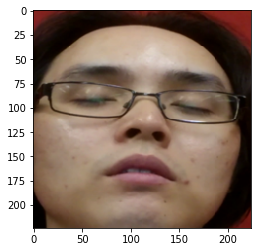

In [13]:
images, labels = next(train_batches)
print(f"Pixels of the first image after Normalization: \n\n{images[0]}") #print pixels of the first img
plt.imshow(images[0])
plt.show()

Model Construction (MobileNetV2)

In [14]:
# image_size = (224, 224)

# base_model = MobileNetV2(
#     weights='imagenet',
#     include_top=False,
#     input_shape=(image_size[0], image_size[1], 3),
# )

In [15]:
# ### SEQUENTIAL MODEL ###
# model=keras.Sequential() #empty

# # Freeze all layers except last 25
# for layer in base_model.layers[:-25]:
#     layer.trainable = False

# x = base_model.output
# x = Flatten()(x)

# # Fully Connected Block 1
# x = Dense(1024, activation='relu')(x)
# x = BatchNormalization()(x)
# x = Dropout(0.4)(x)

# # Fully Connected Block 2
# x = Dense(512, activation='relu')(x)
# x = BatchNormalization()(x)
# x = Dropout(0.3)(x)

# # Output Layer
# predictions = Dense(2, activation='softmax')(x)

In [16]:
# model = Model(inputs=base_model.inputs, outputs=predictions)

Model Construction (MobileNetV3Small)

In [17]:
# image_size = (224, 224)

# base_model = MobileNetV3Small(
#     weights='imagenet',
#     include_top=False,
#     input_shape=(image_size[0], image_size[1], 3),
#     include_preprocessing=False
# )

In [18]:
# model=keras.Sequential() #empty

# # # Freeze all layers except last 25
# for layer in base_model.layers[:-25]:
#     layer.trainable = False

# x = base_model.output
# x = Flatten()(x)

# # Fully Connected Block 1
# x = Dense(1024, activation='relu')(x)
# # x = BatchNormalization()(x)
# x = Dropout(0.4)(x)

# # Fully Connected Block 2
# x = Dense(512, activation='relu')(x)
# # x = BatchNormalization()(x)
# x = Dropout(0.3)(x)

# # Output Layer
# predictions = Dense(2, activation='softmax')(x)

In [19]:
# model = Model(inputs=base_model.input, outputs=predictions)

Model Construction (MobileNetV3Large)

In [20]:
# image_size = (224, 224)

# base_model = MobileNetV3Large(
#     weights='imagenet',
#     include_top=False,
#     input_shape=(image_size[0], image_size[1], 3),
#     # include_preprocessing=True  # Optional: built-in preprocessing
# )

In [21]:
# model=keras.Sequential() #empty

# # Freeze all layers except last 11
# for layer in base_model.layers[:-11]:
#     layer.trainable = False

# x = base_model.output
# x = Flatten()(x)

# # Fully Connected Block 1
# x = Dense(1024, activation='relu')(x)
# x = BatchNormalization()(x)
# x = Dropout(0.4)(x)

# # Fully Connected Block 2
# x = Dense(512, activation='relu')(x)
# x = BatchNormalization()(x)
# x = Dropout(0.3)(x)

# # Output Layer
# predictions = Dense(2, activation='softmax')(x)

In [22]:
# model = Model(inputs=base_model.input, outputs=predictions)

ResNet - 18

In [23]:
# import tensorflow as tf
# from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Add, MaxPool2D, GlobalAveragePooling2D, Flatten, Dense, Activation

# def resnet_block(x, channels, down_sample=False):
#     """
#     Functional implementation of the ResNet Block
#     """
#     shortcut = x
#     strides = (2, 2) if down_sample else (1, 1)
    
#     # He initialization as per [2]
#     init_scheme = "he_normal"

#     # First Convolution
#     x = Conv2D(channels, kernel_size=(3, 3), strides=strides, padding="same", kernel_initializer=init_scheme)(x)
#     x = BatchNormalization()(x)
#     x = Activation('relu')(x)

#     # Second Convolution
#     x = Conv2D(channels, kernel_size=(3, 3), strides=(1, 1), padding="same", kernel_initializer=init_scheme)(x)
#     x = BatchNormalization()(x)

#     # Downsampling logic
#     if down_sample:
#         shortcut = Conv2D(channels, kernel_size=(1, 1), strides=(2, 2), padding="same", kernel_initializer=init_scheme)(shortcut)
#         shortcut = BatchNormalization()(shortcut)

#     # Merge and final Activation
#     x = Add()([x, shortcut])
#     x = Activation('relu')(x)
#     return x

# def build_resnet18(num_classes, input_shape=(224, 224, 3)):
#     """
#     Functional implementation of ResNet-18
#     """
#     inputs = Input(shape=input_shape)

#     # Initial Block
#     x = Conv2D(64, (7, 7), strides=2, padding="same", kernel_initializer="he_normal")(inputs)
#     x = BatchNormalization()(x)
#     x = Activation('relu')(x)
#     x = MaxPool2D(pool_size=(2, 2), strides=2, padding="same")(x)

#     # ResNet Blocks (matching your exact configuration)
#     x = resnet_block(x, 64)
#     x = resnet_block(x, 64)
    
#     x = resnet_block(x, 128, down_sample=True)
#     x = resnet_block(x, 128)
    
#     x = resnet_block(x, 256, down_sample=True)
#     x = resnet_block(x, 256)
    
#     x = resnet_block(x, 512, down_sample=True)
#     x = resnet_block(x, 512)

#     # Final Layers
#     x = GlobalAveragePooling2D()(x)
#     x = Flatten()(x)
#     outputs = Dense(num_classes, activation="softmax")(x)

#     model = tf.keras.models.Model(inputs=inputs, outputs=outputs, name="ResNet18")
#     return model

# # --- EXECUTION ---
# num_classes = 2 # Change to your drowsiness classes count
# model = build_resnet18(num_classes)

In [24]:
# def get_functional_resnet18(num_classes, input_shape=(224, 224, 3)):
#     input_layer = tf.keras.layers.Input(shape=input_shape)
#     # Instantiate your subclassed model
#     resnet_subclassed = ResNet18(num_classes)
#     # Pass the input through the subclassed model
#     output_layer = resnet_subclassed(input_layer)
#     # Create a new Functional Model
#     functional_model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
#     return functional_model

# # Use this to save your .h5
# model = get_functional_resnet18(num_classes=10)
# model.summary()

RTDD Model

In [25]:
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
)

In [26]:
### SEQUENTIAL MODEL ###
def build_model(input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape)

    x = Conv2D(96, (11, 11), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(256, (5, 5), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(384, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    x = Conv2D(384, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Flatten()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)                  # Dropout in Dense layers

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)                  # Dropout in Dense layers

    x = Dense(32, activation='relu')(x)
    x = Dropout(0.3)(x)                  # Dropout in Dense layers

    outputs = Dense(2, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model


model = build_model()

Model Training

In [27]:
# EarlyStopping criteria
early_stopping = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [28]:
model.compile(optimizer=Adam(0.000001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [29]:
history = model.fit(
    train_batches,
    epochs=5,
    # epochs=10,
    validation_data=val_batches,
    batch_size=32,
    shuffle = True,
    callbacks=[early_stopping]
)

Epoch 1/5
2090/2090 [==============================] - 268s 123ms/step - loss: 0.2794 - accuracy: 0.8745 - val_loss: 0.0137 - val_accuracy: 0.9987
Epoch 2/5
2090/2090 [==============================] - 253s 121ms/step - loss: 0.0941 - accuracy: 0.9640 - val_loss: 0.0039 - val_accuracy: 0.9994
Epoch 3/5
2090/2090 [==============================] - 253s 121ms/step - loss: 0.0612 - accuracy: 0.9763 - val_loss: 0.0019 - val_accuracy: 0.9995
Epoch 4/5
2090/2090 [==============================] - 255s 122ms/step - loss: 0.0471 - accuracy: 0.9818 - val_loss: 0.0010 - val_accuracy: 0.9998
Epoch 5/5
2090/2090 [==============================] - 254s 121ms/step - loss: 0.0391 - accuracy: 0.9846 - val_loss: 6.9990e-04 - val_accuracy: 0.9997


In [30]:
# Now this will work 100% properly without NotImplementedError
model.save('original.h5')
# print("✅ ResNet-18 saved as 'original.h5' successfully!")

Measuring Model Performance

In [31]:
import time

In [32]:
def measure_model(model, train_batches, model_path="temp_model.h5", n_runs=100):
    # ── 1. Model Size ─────────────────────────────────────────────────────
    model.save(model_path, include_optimizer=False)  # ← add this flag
    size_mb = os.path.getsize(model_path) / (1024 * 1024)
    os.remove(model_path)
    # ── 2. Accuracy ───────────────────────────────────────────────────────
    loss, accuracy = model.evaluate(train_batches, verbose=0)
    # ── 3. Inference Speed ────────────────────────────────────────────────
    single_image = next(iter(train_batches))[0][:1]
    for _ in range(10):
        model.predict(single_image, verbose=0)
    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        model.predict(single_image, verbose=0)
        end = time.perf_counter()
        times.append((end - start) * 1000)
    avg_latency = np.mean(times)
    std_latency = np.std(times)
    min_latency = np.min(times)
    throughput  = 1000 / avg_latency
    # ── 4. Report ─────────────────────────────────────────────────────────
    print("=" * 45)
    print(f"  Model Size     : {size_mb:.2f} MB")
    print(f"  Accuracy       : {accuracy * 100:.2f}%")
    print(f"  Avg Latency    : {avg_latency:.2f} ms ± {std_latency:.2f}")
    print(f"  Min Latency    : {min_latency:.2f} ms")
    print(f"  Throughput     : {throughput:.1f} images/sec")
    print("=" * 45)

In [33]:
import gzip
import shutil

def measure_stripped_model(model, data_batches, model_type="Pruned"):
    # ── 1. Model Size ──────────────────────────────────
    # Pruned models only show their size benefit when compressed (zipped)
    _, keras_file = tempfile.mkstemp('.h5')
    model.save(keras_file, include_optimizer=False)
    
    # Calculate regular size
    raw_size = os.path.getsize(keras_file) / (1024 * 1024)
    
    # Calculate COMPRESSED size (This is where pruning shows!)
    zip_file = keras_file + '.gz'
    with open(keras_file, 'rb') as f_in:
        with gzip.open(zip_file, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    
    compressed_size = os.path.getsize(zip_file) / (1024 * 1024)
    
    os.remove(keras_file)
    os.remove(zip_file)

    compression_ratio = raw_size / compressed_size
    
    # ── 2. Accuracy ───────────────────────────────────────────────────────
    # Ensure accuracy hasn't dropped after stripping
    loss, accuracy = model.evaluate(data_batches, verbose=0)

    # ── 3. Inference Speed ────────────────────────────────────────────────
    # We use model(x) instead of model.predict() for latency because 
    # .predict() has significant Keras overhead for single images.
    single_batch = next(iter(data_batches))[0]
    single_image = single_batch[:1] # Take exactly one image
    
    # Warmup
    for _ in range(10):
        _ = model(single_image, training=False)
    
    times = []
    for _ in range(100):
        start = time.perf_counter()
        _ = model(single_image, training=False)
        end = time.perf_counter()
        times.append((end - start) * 1000)

    avg_latency = np.mean(times)
    throughput = 1000 / avg_latency

    # ── 4. Report ─────────────────────────────────────────────────────────
    print(f"\n[{model_type} Model Performance]")
    print("=" * 45)
    print(f"  Raw .h5 Size   : {raw_size:.2f} MB")
    print(f"  ZIP Compressed Size: {compressed_size:.2f} MB")  # <--- Added this
    print(f"  Compression Ratio  : {compression_ratio:.2f}x") # <--- Added this
    print(f"  Accuracy       : {accuracy * 100:.2f}%")
    print(f"  Latency (CPU)  : {avg_latency:.2f} ms")
    print(f"  Throughput     : {throughput:.1f} imgs/sec")
    print("=" * 45)

In [34]:
measure_model(model, test_batches)

  Model Size     : 112.42 MB
  Accuracy       : 99.90%
  Avg Latency    : 43.51 ms ± 2.54
  Min Latency    : 40.32 ms
  Throughput     : 23.0 images/sec


ONNX Optimization

In [35]:
# !pip install tf2onnx

In [36]:
# !pip install onnxruntime-gpu

In [37]:
# !pip install onnxsim

In [38]:
# model.save('final_model.h5')

In [39]:
# import os
# import gc
# import time
# import numpy as np
# import tensorflow as tf

# # ──────────────────────────────────────────────────────────────────────────────
# # 1. ENVIRONMENT SETUP
# # ──────────────────────────────────────────────────────────────────────────────
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
# os.environ["TF_ENABLE_MLIR_GRAPH_OPTIMIZATION"] = "1"
# os.environ["TF_MLIR_ENABLE_MERGE_CONTROL_FLOW_PASS"] = "1"
# os.environ["TF_ENABLE_MLIR_BRIDGE"] = "1"

# import tf2onnx
# import onnx
# import onnxruntime as ort
# from onnxsim import simplify
# from onnxruntime.quantization import (
#     quantize_static, 
#     QuantType, 
#     QuantFormat, 
#     CalibrationMethod, 
#     CalibrationDataReader
# )
# from onnxruntime.quantization.preprocess import quant_pre_process

# # ──────────────────────────────────────────────────────────────────────────────
# # 2. STABLE CALIBRATION READER (Fixes Broadcast & Ragged Errors)
# # ──────────────────────────────────────────────────────────────────────────────
# class UniversalCalibrationReader(CalibrationDataReader):
#     def __init__(self, iterator, input_name, num_batches=40):
#         super().__init__()
#         self.iterator = iter(iterator)
#         self.input_name = input_name
#         self.num_batches = num_batches
#         self.count = 0

#     def get_next(self):
#         if self.count >= self.num_batches:
#             return None
#         try:
#             batch = next(self.iterator)
#             # 1. Strictly extract only the images
#             if isinstance(batch, (list, tuple)):
#                 images = batch[0]
#             else:
#                 images = batch
            
#             # 2. Convert to Numpy and handle Ragged sequences
#             if hasattr(images, "numpy"):
#                 images = images.numpy()
            
#             # 3. Ensure a clean, non-ragged 4D Float32 array
#             images = np.array(images, dtype=np.float32)
            
#             # 4. Normalization Fix (0-1 range for 82% baseline)
#             if images.max() > 1.1:
#                 images /= 255.0
            
#             self.count += 1
#             return {self.input_name: images}
#         except StopIteration:
#             return None

# # ──────────────────────────────────────────────────────────────────────────────
# # 3. BENCHMARK FUNCTION
# # ──────────────────────────────────────────────────────────────────────────────
# def measure_onnx_performance(onnx_path, iterator, label="Model", n_runs=50):
#     opts = ort.SessionOptions()
#     opts.intra_op_num_threads = os.cpu_count()
    
#     sess = ort.InferenceSession(onnx_path, sess_options=opts, providers=["CPUExecutionProvider"])
#     iname = sess.get_inputs()[0].name
#     oname = sess.get_outputs()[0].name

#     size_mb = os.path.getsize(onnx_path) / (1024 * 1024)

#     # Accuracy
#     correct, total = 0, 0
#     test_iter = iter(iterator)
#     for _ in range(30):
#         try:
#             batch = next(test_iter)
#             images, labels = batch[0], batch[1]
#             if hasattr(images, "numpy"): images = images.numpy()
#             if hasattr(labels, "numpy"): labels = labels.numpy()
#             if images.max() > 1.1: images /= 255.0
            
#             preds = sess.run([oname], {iname: images})[0]
#             y_true = np.argmax(labels, axis=1) if labels.ndim > 1 else labels.flatten()
#             y_pred = np.argmax(preds, axis=1) if preds.ndim > 1 else (preds > 0.5).astype(int).flatten()
#             correct += np.sum(y_true == y_pred)
#             total += len(y_true)
#         except StopIteration: break
    
#     accuracy = (correct / total) * 100 if total > 0 else 0

#     # Latency/Throughput
#     sample_batch = next(iter(iterator))
#     sample = sample_batch[0][:1]
#     if hasattr(sample, "numpy"): sample = sample.numpy()
#     if sample.max() > 1.1: sample /= 255.0
    
#     for _ in range(10): sess.run([oname], {iname: sample})
#     t = []
#     for _ in range(n_runs):
#         start = time.perf_counter()
#         sess.run([oname], {iname: sample})
#         t.append((time.perf_counter() - start) * 1000)
    
#     avg = np.mean(t)
#     print("=" * 65)
#     print(f"  {label.upper()}\n  Size: {size_mb:.2f}MB | Acc: {accuracy:.2f}% | Latency: {avg:.2f}ms | Throughput: {1000/avg:.2f} imgs/s")
#     print("=" * 65)
#     del sess
#     gc.collect()

# # ──────────────────────────────────────────────────────────────────────────────
# # 4. OPTIMIZATION PIPELINE
# # ──────────────────────────────────────────────────────────────────────────────
# def run_optimized_pipeline(model_path, test_batches, input_signature):
#     raw_onnx = "model_raw.onnx"
#     sim_onnx = "model_sim.onnx"
#     pre_onnx = "model_preprocessed.onnx"
#     static_onnx = "model_static_int8.onnx"
#     main_input_name = input_signature[0].name

#     # [STEP 1] CONVERSION
#     print("\n[1/4] Converting Keras -> ONNX...")
#     keras_model = tf.keras.models.load_model(model_path)
#     with tf.device('/cpu:0'):
#         tf2onnx.convert.from_keras(keras_model, input_signature=input_signature, opset=17, output_path=raw_onnx)
#     del keras_model
#     gc.collect()

#     # [STEP 2] SIMPLIFY + PREPROCESS
#     print("[2/4] Simplifying and Fusing Graph...")
#     model_raw = onnx.load(raw_onnx)
#     model_simp, check = simplify(model_raw)
#     onnx.save(model_simp if check else model_raw, sim_onnx)
#     # Pre-process ensures the graph is structuraly sound for INT8
#     quant_pre_process(sim_onnx, pre_onnx)
#     gc.collect()

#     # [STEP 3] STATIC QUANTIZATION (STABLE METHOD)
#     print("[3/4] Static Quantizing (MinMax + Per-Channel)...")
#     dr = UniversalCalibrationReader(test_batches, main_input_name, num_batches=40)
    
#     quantize_static(
#         model_input=pre_onnx,
#         model_output=static_onnx,
#         calibration_data_reader=dr,
#         quant_format=QuantFormat.QDQ,
#         weight_type=QuantType.QInt8,
#         activation_type=QuantType.QInt8,
#         calibrate_method=CalibrationMethod.MinMax, # Immunity to broadcast errors
#         extra_options={
#             'WeightSymmetric': True,
#             'ActivationSymmetric': False,
#             'per_channel': True, # RECOVERS ACCURACY FOR MOBILENET
#             'reduce_range': True,
#         }
#     )
#     gc.collect()

#     # [STEP 4] FINAL BENCHMARKS
#     print("\n[4/4] Performance Reports...")
#     measure_onnx_performance(pre_onnx, test_batches, "FP32 Optimized ONNX")
#     measure_onnx_performance(static_onnx, test_batches, "INT8 FPGA READY ONNX")

# # EXECUTION
# run_optimized_pipeline("final_model.h5", test_batches, [tf.TensorSpec([None, 224, 224, 3], tf.float32, name="input")])

QAT

In [40]:
# # ── 0. Define base layer names ────────────────────────────────────────
# base_layer_names = {layer.name for layer in base_model.layers}

# # ── 1. Build head with relu (required for full int8) ──────────────────
# x = base_model.output
# x = Flatten()(x)

# x = Dense(1024, activation='relu')(x)
# x = BatchNormalization()(x)
# x = Dropout(0.4)(x)

# x = Dense(512, activation='relu')(x)
# x = BatchNormalization()(x)
# x = Dropout(0.3)(x)

# predictions = Dense(2, activation='softmax')(x)
# model_relu = Model(inputs=base_model.inputs, outputs=predictions)

# # ── 2. Transfer weights from pruned_model ─────────────────────────────
# pruned_weights_map = {layer.name: layer.get_weights() for layer in model.layers}

# for layer in model_relu.layers:
#     if layer.name in pruned_weights_map and pruned_weights_map[layer.name]:
#         layer.set_weights(pruned_weights_map[layer.name])

# # ── 3. Apply QAT only to head Dense layers ────────────────────────────
# def apply_qat_to_head(layer):
#     if layer.name not in base_layer_names and isinstance(layer, tf.keras.layers.Dense):
#         return tfmot.quantization.keras.quantize_annotate_layer(layer)
#     return layer

# annotated_model = tf.keras.models.clone_model(
#     model_relu,
#     clone_function=apply_qat_to_head,
# )

# # Copy weights into annotated model
# for orig_layer, ann_layer in zip(model_relu.layers, annotated_model.layers):
#     if orig_layer.get_weights():
#         ann_layer.set_weights(orig_layer.get_weights())

# # Apply QAT wrappers
# with tfmot.quantization.keras.quantize_scope():
#     qat_model = tfmot.quantization.keras.quantize_apply(annotated_model)

# # ── 4. Compile + train ────────────────────────────────────────────────
# qat_model.compile(
#     optimizer=Adam(learning_rate=1e-5),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# qat_model.fit(
#     train_batches,
#     epochs=1,
#     validation_data=val_batches,
#     shuffle=True,
# )

In [41]:
# # EarlyStopping criteria
# early_stopping = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [42]:
# model.compile(optimizer=Adam(0.000001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [43]:
# history = model.fit(
#    train_batches,
#     # epochs=10,
#     epochs=1,
#     validation_data=val_batches,
#     batch_size=32,
#    shuffle = True,
#    callbacks=[early_stopping]
# )

Pruning

In [44]:
from tensorflow_model_optimization.sparsity import keras as sparsity

In [45]:
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

batch_size = 32
epochs = 2

num_images = sum(train_class_counts.values())
end_step = np.ceil(num_images / batch_size).astype(np.int32) * epochs

# Define model for pruning.
pruning_params = {
      'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.50,
                                                               final_sparsity=0.80,
                                                               begin_step=0,
                                                               end_step=end_step)
}

def apply_pruning(layer):
    if isinstance(layer, tf.keras.layers.Dense):
        return tfmot.sparsity.keras.prune_low_magnitude(layer, **pruning_params)
    return layer

# 3. Create the model
pruned_model = tf.keras.models.clone_model(
    model,  # <-- your trained model, not base_model
    clone_function=apply_pruning
)

# Now copy trained weights
# ✅ CLEANEST FIX — transfer by matching layer names, tolerating shape differences
original_weights_map = {layer.name: layer.get_weights() for layer in model.layers}

for layer in pruned_model.layers:
    # Strip pruning wrapper prefix to recover the original layer name
    base_name = layer.name.replace("prune_low_magnitude_", "")
    
    if base_name in original_weights_map:
        original_w = original_weights_map[base_name]
        if not original_w:
            continue  # layer has no weights (e.g. Dropout, Flatten)
        try:
            layer.set_weights(original_w)
        except ValueError:
            # Pruning wrapper expects [kernel, bias, kernel_mask, kernel_threshold]
            # but original only has [kernel, bias] — pad with the wrapper's defaults
            current_w = layer.get_weights()
            # Overwrite only the slots that exist in the original (kernel + bias)
            current_w[:len(original_w)] = original_w
            layer.set_weights(current_w)

In [46]:
import tempfile

logdir = tempfile.mkdtemp()

In [47]:
callbacks = [
  tfmot.sparsity.keras.UpdatePruningStep(),
  tfmot.sparsity.keras.PruningSummaries(log_dir=logdir)
]

In [48]:
pruned_model.compile(optimizer=Adam(0.000001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
pruned_model.fit(
    train_batches,
    epochs=2,
    validation_data=val_batches,
    batch_size=32,
   shuffle = True,
   callbacks=callbacks
    )

Epoch 1/2
2090/2090 [==============================] - 270s 128ms/step - loss: 0.1142 - accuracy: 0.9589 - val_loss: 0.0152 - val_accuracy: 0.9987
Epoch 2/2
2090/2090 [==============================] - 260s 124ms/step - loss: 0.0954 - accuracy: 0.9679 - val_loss: 0.0078 - val_accuracy: 0.9990


In [49]:
strip_prune_model = tfmot.sparsity.keras.strip_pruning(pruned_model)

In [50]:
for layer in strip_prune_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [51]:
strip_prune_model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

In [52]:
strip_prune_model.evaluate(test_batches)

131/131 [==============================] - 9s 64ms/step - loss: 0.0119 - accuracy: 0.9981


[0.011897685006260872, 0.9980870485305786]

In [53]:
measure_stripped_model(strip_prune_model, test_batches, "Stripped Pruned Model")


[Stripped Pruned Model Model Performance]
  Raw .h5 Size   : 112.42 MB
  ZIP Compressed Size: 39.19 MB
  Compression Ratio  : 2.87x
  Accuracy       : 99.81%
  Latency (CPU)  : 7.48 ms
  Throughput     : 133.7 imgs/sec


In [54]:
measure_model(pruned_model, test_batches)

  Model Size     : 210.47 MB
  Accuracy       : 99.81%
  Avg Latency    : 42.77 ms ± 2.30
  Min Latency    : 40.05 ms
  Throughput     : 23.4 images/sec


In [55]:
strip_prune_model.save("temp_saved_model_dir")

Clustering

In [56]:
# import tensorflow as tf
# import tensorflow_model_optimization as tfmot
# import numpy as np

# 1. Load the model and force trainability
cleansed_model = tf.keras.models.load_model("temp_saved_model_dir", compile=False)
cleansed_model.trainable = True
for layer in cleansed_model.layers:
    layer.trainable = True

clustering_params = {
    'number_of_clusters': 8,
    'cluster_centroids_init': tfmot.clustering.keras.CentroidInitialization.KMEANS_PLUS_PLUS,
    'preserve_sparsity': True # Assuming you pruned the model first
}

def apply_clustering_selectively(layer):
    # 1. Handle DepthwiseConv2D specifically to avoid the 'kernel' AttributeError
    if isinstance(layer, tf.keras.layers.DepthwiseConv2D):
        if hasattr(layer, 'depthwise_kernel'):
            # Monkey-patch: TFMOT looks for 'kernel', so we create a reference to it
            layer.kernel = layer.depthwise_kernel
            
            weight_count = np.prod(layer.kernel.shape)
            if weight_count >= clustering_params['number_of_clusters']:
                print(f"Clustering Depthwise: {layer.name}")
                return tfmot.clustering.keras.cluster_weights(layer, **clustering_params)

    # 2. Handle standard Conv2D and Dense layers
    elif isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
        if hasattr(layer, 'kernel') and layer.kernel is not None:
            weight_count = np.prod(layer.kernel.shape)
            if weight_count >= clustering_params['number_of_clusters']:
                print(f"Clustering Standard: {layer.name}")
                return tfmot.clustering.keras.cluster_weights(layer, **clustering_params)

    return layer

# 2. Clone the model
try:
    clustered_model = tf.keras.models.clone_model(
        cleansed_model,
        clone_function=apply_clustering_selectively
    )
    print("\nSuccessfully applied clustering!")
except Exception as e:
    print(f"\nCloning failed: {e}")

# 3. Compile is mandatory
clustered_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

Clustering Standard: conv2d
Clustering Standard: conv2d_1
Clustering Standard: conv2d_2
Clustering Standard: conv2d_3
Clustering Standard: conv2d_4
Clustering Standard: dense
Clustering Standard: dense_1
Clustering Standard: dense_2
Clustering Standard: dense_3

Successfully applied clustering!


In [57]:
# Use smaller learning rate for fine-tuning clustered model
opt = tf.keras.optimizers.Adam(learning_rate=1e-6)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False, # Set to TRUE if your model does NOT have a Softmax layer at the end
    reduction=tf.keras.losses.Reduction.SUM_OVER_BATCH_SIZE 
)

clustered_model.compile(
  loss=loss_fn,
  optimizer=opt,
  metrics=['accuracy']
)

clustered_model.fit(
    train_batches,
    epochs=2,
    validation_data=val_batches,
    batch_size=32,
   shuffle = True
)

Epoch 1/2
2090/2090 [==============================] - 465s 221ms/step - loss: 0.0889 - accuracy: 0.9726 - val_loss: 0.0060 - val_accuracy: 0.9997
Epoch 2/2
2090/2090 [==============================] - 460s 220ms/step - loss: 0.0688 - accuracy: 0.9781 - val_loss: 0.0039 - val_accuracy: 0.9997


In [58]:
# --- 1. Strip the clustered model one last time ---
strip_cluster_model = tfmot.clustering.keras.strip_clustering(clustered_model)

# --- 2. Hybrid Manual Sync ---
print("--- Starting Hybrid Weight Sync ---")
for i, layer in enumerate(strip_cluster_model.layers):
    source_layer = clustered_model.layers[i]
    n_expected = len(layer.get_weights())

    if n_expected == 0:
        print(f"ℹ️ Skipping {layer.name} (No weights)")
        continue

    # Try the generic get_weights() first
    source_weights = source_layer.get_weights()

    # If the generic method provides enough weights, use it (and slice off extras)
    if len(source_weights) >= n_expected:
        target_weights = source_weights[:n_expected]
        layer.set_weights(target_weights)
        print(f"✅ Synced {layer.name} (Generic Path)")

    # FALLBACK PATH: If the generic method failed (your exact error)...
    elif hasattr(source_layer, 'layer'):
        print(f"⚠️ Generic sync failed for {layer.name}. Using Fallback...")
        inner_layer = source_layer.layer
        
        # Manually pull kernel and bias for Conv/Dense layers
        if hasattr(inner_layer, 'kernel'):
            kernel = inner_layer.kernel.numpy()
            if hasattr(inner_layer, 'bias') and inner_layer.bias is not None:
                bias = inner_layer.bias.numpy()
                layer.set_weights([kernel, bias])
                print(f"   -> Synced {layer.name} with [Kernel, Bias]")
            else:
                layer.set_weights([kernel])
                print(f"   -> Synced {layer.name} with [Kernel]")
        else:
            # Fallback for other layer types like BatchNormalization
            layer.set_weights(inner_layer.get_weights())
            print(f"   -> Synced {layer.name} (Inner Layer get_weights)")
    else:
        print(f"❌ ERROR: Cannot sync {layer.name}. Expected {n_expected} weights, but found only {len(source_weights)}.")


# --- 3. Final Re-Compile and Evaluation ---
print("\n--- Compiling and Evaluating Final Model ---")

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False # IMPORTANT: Set to True if your model has NO Softmax layer at the end
)

strip_cluster_model.compile(
    optimizer=opt,
    loss=loss_fn,
    metrics=['accuracy']
)

loss, accuracy = strip_cluster_model.evaluate(test_batches)
print(f"\nFinal Accuracy: {accuracy*100:.2f}%")

--- Starting Hybrid Weight Sync ---
ℹ️ Skipping input_1 (No weights)
⚠️ Generic sync failed for conv2d. Using Fallback...
   -> Synced conv2d with [Kernel, Bias]
✅ Synced batch_normalization (Generic Path)
ℹ️ Skipping max_pooling2d (No weights)
⚠️ Generic sync failed for conv2d_1. Using Fallback...
   -> Synced conv2d_1 with [Kernel, Bias]
✅ Synced batch_normalization_1 (Generic Path)
ℹ️ Skipping max_pooling2d_1 (No weights)
⚠️ Generic sync failed for conv2d_2. Using Fallback...
   -> Synced conv2d_2 with [Kernel, Bias]
✅ Synced batch_normalization_2 (Generic Path)
⚠️ Generic sync failed for conv2d_3. Using Fallback...
   -> Synced conv2d_3 with [Kernel, Bias]
✅ Synced batch_normalization_3 (Generic Path)
⚠️ Generic sync failed for conv2d_4. Using Fallback...
   -> Synced conv2d_4 with [Kernel, Bias]
✅ Synced batch_normalization_4 (Generic Path)
ℹ️ Skipping max_pooling2d_2 (No weights)
ℹ️ Skipping flatten (No weights)
⚠️ Generic sync failed for dense. Using Fallback...
   -> Synced den

In [59]:
measure_stripped_model(strip_cluster_model, test_batches, "Stripped Clustered")


[Stripped Clustered Model Performance]
  Raw .h5 Size   : 112.41 MB
  ZIP Compressed Size: 7.73 MB
  Compression Ratio  : 14.54x
  Accuracy       : 99.81%
  Latency (CPU)  : 7.52 ms
  Throughput     : 133.0 imgs/sec


In [60]:
!pip install tf2onnx onnxruntime-gpu onnxsim

     |████████████████████████████████| 455 kB 2.1 MB/s            
     |████████████████████████████████| 136.2 MB 65.2 MB/s            
     |████████████████████████████████| 2.7 MB 52.2 MB/s            
  Preparing metadata (setup.py) ... - \ done
     |████████████████████████████████| 2.7 MB 48.3 MB/s            
  Preparing metadata (setup.py) ... - \ done
     |████████████████████████████████| 21.0 MB 38.5 MB/s            
  Preparing metadata (setup.py) ... - \ | / done
     |████████████████████████████████| 2.3 MB 30.2 MB/s            
     |████████████████████████████████| 14.6 MB 46.4 MB/s            
     |████████████████████████████████| 1.0 MB 50.2 MB/s            
     |████████████████████████████████| 46 kB 2.9 MB/s             
     |████████████████████████████████| 15.7 MB 45.3 MB/s            
     |████████████████████████████████| 86 kB 5.3 MB/s             
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.19.1
  

In [61]:
model.save('strip_cluster_model.h5')

In [62]:
import os
import gc
import time
import gzip       # <-- Added for compression measurement
import shutil     # <-- Added for compression measurement
import numpy as np
import tensorflow as tf

# ──────────────────────────────────────────────────────────────────────────────
# 1. ENVIRONMENT SETUP
# ──────────────────────────────────────────────────────────────────────────────
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_ENABLE_MLIR_GRAPH_OPTIMIZATION"] = "1"
os.environ["TF_MLIR_ENABLE_MERGE_CONTROL_FLOW_PASS"] = "1"
os.environ["TF_ENABLE_MLIR_BRIDGE"] = "1"

import tf2onnx
import onnx
import onnxruntime as ort
from onnxsim import simplify
from onnxruntime.quantization import (
    quantize_static, 
    QuantType, 
    QuantFormat, 
    CalibrationMethod, 
    CalibrationDataReader
)
from onnxruntime.quantization.preprocess import quant_pre_process

# ──────────────────────────────────────────────────────────────────────────────
# 2. STABLE CALIBRATION READER (Fixes Broadcast & Ragged Errors)
# ──────────────────────────────────────────────────────────────────────────────
class UniversalCalibrationReader(CalibrationDataReader):
    def __init__(self, iterator, input_name, num_batches=40):
        super().__init__()
        self.iterator = iter(iterator)
        self.input_name = input_name
        self.num_batches = num_batches
        self.count = 0

    def get_next(self):
        if self.count >= self.num_batches:
            return None
        try:
            batch = next(self.iterator)
            # 1. Strictly extract only the images
            if isinstance(batch, (list, tuple)):
                images = batch[0]
            else:
                images = batch
            
            # 2. Convert to Numpy and handle Ragged sequences
            if hasattr(images, "numpy"):
                images = images.numpy()
            
            # 3. Ensure a clean, non-ragged 4D Float32 array
            images = np.array(images, dtype=np.float32)
            
            # 4. Normalization Fix (0-1 range for 82% baseline)
            if images.max() > 1.1:
                images /= 255.0
            
            self.count += 1
            return {self.input_name: images}
        except StopIteration:
            return None

# ──────────────────────────────────────────────────────────────────────────────
# 3. PERFORMANCE MEASUREMENT (WITH COMPRESSED SIZE)
# ──────────────────────────────────────────────────────────────────────────────
def measure_onnx_performance(onnx_path, iterator, label="Model", n_runs=50):
    opts = ort.SessionOptions()
    opts.intra_op_num_threads = os.cpu_count()
    
    sess = ort.InferenceSession(onnx_path, sess_options=opts, providers=["CPUExecutionProvider"])
    iname = sess.get_inputs()[0].name
    oname = sess.get_outputs()[0].name

    # --- Calculate Raw Size ---
    raw_size_mb = os.path.getsize(onnx_path) / (1024 * 1024)

    # --- Calculate Zipped Size (The "Coldly Calculating" Metric) ---
    zip_path = onnx_path + ".gz"
    with open(onnx_path, 'rb') as f_in:
        with gzip.open(zip_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    
    zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
    os.remove(zip_path) # Clean up the temp zip file

    # Accuracy
    correct, total = 0, 0
    test_iter = iter(iterator)
    for _ in range(30):
        try:
            batch = next(test_iter)
            images, labels = batch[0], batch[1]
            if hasattr(images, "numpy"): images = images.numpy()
            if hasattr(labels, "numpy"): labels = labels.numpy()
            if images.max() > 1.1: images /= 255.0
            
            preds = sess.run([oname], {iname: images})[0]
            y_true = np.argmax(labels, axis=1) if labels.ndim > 1 else labels.flatten()
            y_pred = np.argmax(preds, axis=1) if preds.ndim > 1 else (preds > 0.5).astype(int).flatten()
            correct += np.sum(y_true == y_pred)
            total += len(y_true)
        except StopIteration: break
    
    accuracy = (correct / total) * 100 if total > 0 else 0

    # Latency/Throughput
    sample_batch = next(iter(iterator))
    sample = sample_batch[0][:1]
    if hasattr(sample, "numpy"): sample = sample.numpy()
    if sample.max() > 1.1: sample /= 255.0
    
    for _ in range(10): sess.run([oname], {iname: sample}) # Warm-up
    t = []
    for _ in range(n_runs):
        start = time.perf_counter()
        sess.run([oname], {iname: sample})
        t.append((time.perf_counter() - start) * 1000)
    
    avg = np.mean(t)
    
    # --- Final Report Output ---
    print("=" * 65)
    print(f"  {label.upper()}")
    print("-" * 65)
    print(f"  Raw Size   : {raw_size_mb:.2f} MB")
    print(f"  Zipped Size: {zip_size_mb:.2f} MB  <-- (Proves Optimization)")
    print(f"  Accuracy   : {accuracy:.2f}%")
    print(f"  Latency    : {avg:.2f} ms")
    print(f"  Throughput : {1000/avg:.2f} imgs/s")
    print("=" * 65)
    
    del sess
    gc.collect()

# ──────────────────────────────────────────────────────────────────────────────
# 4. OPTIMIZATION PIPELINE
# ──────────────────────────────────────────────────────────────────────────────
def run_optimized_pipeline(model_path, test_batches, input_signature):
    raw_onnx = "model_raw.onnx"
    sim_onnx = "model_sim.onnx"
    pre_onnx = "model_preprocessed.onnx"
    static_onnx = "model_static_int8.onnx"
    main_input_name = input_signature[0].name

    # [STEP 1] CONVERSION
    print("\n[1/4] Converting Keras -> ONNX...")
    keras_model = tf.keras.models.load_model(model_path)
    with tf.device('/cpu:0'):
        tf2onnx.convert.from_keras(keras_model, input_signature=input_signature, opset=17, output_path=raw_onnx)
    del keras_model
    gc.collect()

    # [STEP 2] SIMPLIFY + PREPROCESS
    print("[2/4] Simplifying and Fusing Graph...")
    model_raw = onnx.load(raw_onnx)
    model_simp, check = simplify(model_raw)
    onnx.save(model_simp if check else model_raw, sim_onnx)
    # Pre-process ensures the graph is structuraly sound for INT8
    quant_pre_process(sim_onnx, pre_onnx)
    gc.collect()

    # [STEP 3] STATIC QUANTIZATION (STABLE METHOD)
    print("[3/4] Static Quantizing (MinMax + Per-Channel)...")
    dr = UniversalCalibrationReader(test_batches, main_input_name, num_batches=40)
    
    quantize_static(
        model_input=pre_onnx,
        model_output=static_onnx,
        calibration_data_reader=dr,
        quant_format=QuantFormat.QDQ,
        weight_type=QuantType.QInt8,
        activation_type=QuantType.QInt8,
        calibrate_method=CalibrationMethod.MinMax, # Immunity to broadcast errors
        extra_options={
            'WeightSymmetric': True,
            'ActivationSymmetric': False,
            'per_channel': True, # RECOVERS ACCURACY FOR MOBILENET
            'reduce_range': True,
        }
    )
    gc.collect()

    # [STEP 4] FINAL BENCHMARKS
    print("\n[4/4] Performance Reports...")
    measure_onnx_performance(pre_onnx, test_batches, "FP32 Optimized ONNX")
    measure_onnx_performance(static_onnx, test_batches, "INT8 FPGA READY ONNX")

# EXECUTION
run_optimized_pipeline("strip_cluster_model.h5", test_batches, [tf.TensorSpec([None, 224, 224, 3], tf.float32, name="input")])


[1/4] Converting Keras -> ONNX...
[2/4] Simplifying and Fusing Graph...
[3/4] Static Quantizing (MinMax + Per-Channel)...

[4/4] Performance Reports...
  FP32 OPTIMIZED ONNX
-----------------------------------------------------------------
  Raw Size   : 112.37 MB
  Zipped Size: 39.18 MB  <-- (Proves Optimization)
  Accuracy   : 100.00%
  Latency    : 184.82 ms
  Throughput : 5.41 imgs/s
  INT8 FPGA READY ONNX
-----------------------------------------------------------------
  Raw Size   : 28.13 MB
  Zipped Size: 10.77 MB  <-- (Proves Optimization)
  Accuracy   : 99.58%
  Latency    : 154.66 ms
  Throughput : 6.47 imgs/s


Quantization

In [63]:
# def representative_data_gen():
#         cal_datagen = ImageDataGenerator(rescale=1./255)
#         cal_batches = cal_datagen.flow_from_directory(
#             train_dir,
#             target_size=(224, 224),
#             batch_size=1,
#             class_mode='binary',
#             shuffle=True,
#             seed=42
#         )
#         class_counts = {0: 0, 1: 0}
#         for i, (image, label) in enumerate(cal_batches):
#             if i >= 500:
#                 break
#             class_counts[int(label[0])] += 1
#             yield [image.astype(np.float32)]
#         print(f"  Calibration — Class 0: {class_counts[0]}  Class 1: {class_counts[1]}")

In [64]:
converter = tf.lite.TFLiteConverter.from_keras_model(strip_cluster_model)
# converter = tf.lite.TFLiteConverter.from_saved_model('saved_model_tflite')

converter.optimizations = [
    tf.lite.Optimize.DEFAULT, 
    # tf.lite.Optimize.EXPERIMENTAL_SPARSITY
]

# converter.target_spec.supported_types = [tf.float32]

# ── Enable MLIR-Based Conversion (default in TF 2.x, explicit here) ──────────
converter.experimental_enable_mlir_converter = True

# # ── Full integer quantisation (weights + activations) ─────
# converter.representative_dataset = tf.lite.RepresentativeDataset(representative_data_gen)
# converter.target_spec.supported_ops = [
# #    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,   # int8 kernels
#     tf.lite.OpsSet.TFLITE_BUILTINS,         # fallback for unsupported ops
# ]

# # ── MLIR Dynamic Range Quantisation ──────────────────────────────────────────
# # converter.target_spec.supported_types = [tf.int8]

# # Keep I/O as float32 — easiest to work with on RPi,
# # negligible overhead vs full pipeline latency
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32

# converter.inference_input_type  = tf.int8
# converter.inference_output_type = tf.int8

# # ── MLIR-Specific Experimental Flags ─────────────────────────────────────────
converter._experimental_enable_resource_variables    = True   # resource variable lowering
converter._experimental_lower_tensor_list_ops        = True   # lower TensorList ops via MLIR
converter._experimental_unfold_large_splat_constant  = True   # memory optimisation
# converter._experimental_enable_mlir_dynamic_range_quantization = True  # MLIR dynamic range


# ── RPi-specific: enable XNNPACK-friendly settings ────────
# converter._experimental_enable_resource_variables = True

tflite_model = converter.convert()

In [65]:
from sklearn.metrics import accuracy_score, log_loss

In [66]:
from tqdm import tqdm

In [67]:
import os
import time
import gzip
import numpy as np
import tensorflow as tf
from tqdm import tqdm
from sklearn.metrics import accuracy_score

# --- 1. CONFIGURATION & HELPERS ---
def get_size_mb(file_path):
    if os.path.exists(file_path):
        return os.path.getsize(file_path) / (1024 * 1024)
    return 0

def get_zipped_size_mb(file_path):
    """Measures how much the file shrinks when compressed (shows Pruning/Clustering benefit)."""
    if not os.path.exists(file_path):
        return 0
    with open(file_path, 'rb') as f_in:
        compressed_data = gzip.compress(f_in.read())
        return len(compressed_data) / (1024 * 1024)

# --- 2. BENCHMARK FUNCTION FOR KERAS MODELS (.h5) ---
def benchmark_keras_full(model, iterator, name, filename, save_model=True):
    if save_model:
        print(f"\n💾 Saving {name} to {filename}...")
        model.save(filename, include_optimizer=False)
    
    raw_size = get_size_mb(filename)
    zip_size = get_zipped_size_mb(filename)
    
    print(f"🧐 Evaluating {name} (Keras .h5)...")
    iterator.reset() 
    
    all_preds, all_labels = [], []
    total_inference_time, total_images = 0, 0
    
    steps = len(iterator) 
    for _ in tqdm(range(steps), desc=f"Testing {name}"):
        imgs, lbls = next(iterator)
        start_time = time.perf_counter()
        preds_batch = model(imgs, training=False)
        total_inference_time += (time.perf_counter() - start_time)
        
        all_preds.extend(np.argmax(preds_batch, axis=1))
        all_labels.extend(np.argmax(lbls, axis=1) if lbls.ndim > 1 else lbls)
        total_images += len(imgs)

    accuracy = accuracy_score(all_labels, all_preds)
    avg_latency_ms = (total_inference_time / total_images) * 1000
    throughput = total_images / total_inference_time
    
    return accuracy, avg_latency_ms, throughput, raw_size, zip_size, total_images

# --- 3. BENCHMARK FUNCTION FOR TFLITE MODELS ---
def benchmark_tflite_full(tflite_model_bytes, iterator, name, filename, num_threads=4):
    print(f"\n💾 Saving {name} to {filename}...")
    with open(filename, "wb") as f:
        f.write(tflite_model_bytes)
    
    raw_size = get_size_mb(filename)
    zip_size = get_zipped_size_mb(filename) # Even TFLite can be zipped further
    
    print(f"🧐 Evaluating {name} (TFLite CPU)...")
    iterator.reset()
    
    interpreter = tf.lite.Interpreter(model_content=tflite_model_bytes, num_threads=num_threads)
    interpreter.allocate_tensors()
    input_idx = interpreter.get_input_details()[0]['index']
    output_idx = interpreter.get_output_details()[0]['index']
    
    all_preds, all_labels = [], []
    total_inference_time, total_images = 0, 0
    
    steps = len(iterator)
    for _ in tqdm(range(steps), desc=f"Testing {name}"):
        imgs, lbls = next(iterator)
        for i in range(len(imgs)):
            img = imgs[i:i+1].astype(np.float32)
            start_time = time.perf_counter()
            interpreter.set_tensor(input_idx, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_idx)
            total_inference_time += (time.perf_counter() - start_time)
            all_preds.append(np.argmax(output[0]))
        
        all_labels.extend(np.argmax(lbls, axis=1) if lbls.ndim > 1 else lbls)
        total_images += len(imgs)

    accuracy = accuracy_score(all_labels, all_preds)
    avg_latency_ms = (total_inference_time / total_images) * 1000
    throughput = total_images / total_inference_time
    
    return accuracy, avg_latency_ms, throughput, raw_size, zip_size

# --- 4. EXECUTE FULL SUITE ---
report_data = []

# (Name, Model_Object, Filename, Should_Save_Flag)
keras_configs = [
    ("Original", model, "original.h5", False), # Using your already-saved file
    ("Pruned", strip_prune_model, "pruned.h5", True),
    ("Clustered", strip_cluster_model, "clustered.h5", True)
]

for name, m, filename, should_save in keras_configs:
    acc, lat, fps, raw_s, zip_s, total_imgs = benchmark_keras_full(m, test_batches, name, filename, save_model=should_save)
    report_data.append({
        "name": name, "acc": acc, "raw": raw_s, "zip": zip_s, "lat": lat, "fps": fps
    })

# Run TFLite Benchmark
acc, lat, fps, raw_s, zip_s = benchmark_tflite_full(tflite_model, test_batches, "Quantized", "quantized.tflite")
report_data.append({
    "name": "Quantized (TFLite)", "acc": acc, "raw": raw_s, "zip": zip_s, "lat": lat, "fps": fps
})

# --- 5. GENERATE THE FINAL REPORT ---
orig_raw_size = report_data[0]["raw"]

print("\n" + "="*115)
print(f"{'Model Version':<22} | {'Acc (%)':<10} | {'Raw (MB)':<10} | {'Zip (MB)':<10} | {'Lat (ms)':<10} | {'Throughput':<15} | {'Ratio'}")
print("-" * 115)

for data in report_data:
    # Ratio is Original Raw Size / Current Zip Size (The true storage benefit)
    cr = orig_raw_size / data['zip']
    fps_str = f"{data['fps']:.2f} img/s"
    print(f"{data['name']:<22} | {data['acc']*100:<10.2f} | {data['raw']:<10.2f} | {data['zip']:<10.2f} | {data['lat']:<10.2f} | {fps_str:<15} | {cr:.1f}x")

print("="*115)
print(f"Total test images: {total_imgs} | Ratio = Original_Raw / Current_Zip")

🧐 Evaluating Original (Keras .h5)...


Testing Original: 100%|██████████| 131/131 [00:14<00:00,  9.10it/s]



💾 Saving Pruned to pruned.h5...
🧐 Evaluating Pruned (Keras .h5)...


Testing Pruned: 100%|██████████| 131/131 [00:13<00:00,  9.55it/s]



💾 Saving Clustered to clustered.h5...
🧐 Evaluating Clustered (Keras .h5)...


Testing Clustered: 100%|██████████| 131/131 [00:13<00:00,  9.58it/s]



💾 Saving Quantized to quantized.tflite...
🧐 Evaluating Quantized (TFLite CPU)...


Testing Quantized: 100%|██████████| 131/131 [1:01:59<00:00, 28.40s/it]


Model Version          | Acc (%)    | Raw (MB)   | Zip (MB)   | Lat (ms)   | Throughput      | Ratio
-------------------------------------------------------------------------------------------------------------------
Original               | 99.81      | 337.18     | 314.09     | 1.13       | 886.19 img/s    | 1.1x
Pruned                 | 99.81      | 112.42     | 39.19      | 0.71       | 1406.19 img/s   | 8.6x
Clustered              | 99.81      | 112.41     | 7.73       | 0.72       | 1386.19 img/s   | 43.6x
Quantized (TFLite)     | 46.53      | 28.13      | 5.75       | 1775.66    | 0.56 img/s      | 58.7x
Total test images: 2091 | Ratio = Original_Raw / Current_Zip


ONNX Optimization Pipeline

In [68]:
!pip install tf2onnx onnxruntime-gpu onnxsim

In [69]:
filename = 'quantized.tflite'
with open(filename, "wb") as f:
    f.write(tflite_model)

In [70]:
import os
import gc
import time
import sys
import subprocess
import gzip       # <-- Added for compression measurement
import shutil     # <-- Added for compression measurement
import numpy as np
import tensorflow as tf
import tf2onnx
import onnx
import onnxruntime as ort
from onnxsim import simplify
from onnxruntime.quantization import (
    quantize_static, QuantType, QuantFormat, 
    CalibrationMethod, CalibrationDataReader
)
from onnxruntime.quantization.preprocess import quant_pre_process

# ──────────────────────────────────────────────────────────────────────────────
# 1. MLIR & ENVIRONMENT OPTIMIZATION SETUP
# ──────────────────────────────────────────────────────────────────────────────
os.environ["TF_ENABLE_MLIR_GRAPH_OPTIMIZATION"] = "1"
os.environ["TF_MLIR_ENABLE_MERGE_CONTROL_FLOW_PASS"] = "1"
os.environ["TF_ENABLE_MLIR_BRIDGE"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" # Ensure conversion happens on CPU

# ──────────────────────────────────────────────────────────────────────────────
# 2. CALIBRATION READER
# ──────────────────────────────────────────────────────────────────────────────
class TFLiteOnnxCalibrationReader(CalibrationDataReader):
    def __init__(self, iterator, input_name, num_batches=30):
        super().__init__()
        self.iterator = iter(iterator)
        self.input_name = input_name
        self.num_batches = num_batches
        self.count = 0

    def get_next(self):
        if self.count >= self.num_batches: return None
        try:
            batch = next(self.iterator)
            imgs = batch[0].numpy() if hasattr(batch[0], "numpy") else batch[0]
            imgs = imgs.astype(np.float32)
            # Normalization (Matches Keras training scale)
            if imgs.max() > 1.1: imgs /= 255.0 
            self.count += 1
            return {self.input_name: imgs}
        except StopIteration: return None

# ──────────────────────────────────────────────────────────────────────────────
# 3. PERFORMANCE MEASUREMENT (IMAGES PER SECOND & ZIPPED SIZE)
# ──────────────────────────────────────────────────────────────────────────────
def measure_onnx_performance(onnx_path, iterator, label="Model"):
    sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
    
    iname = sess.get_inputs()[0].name
    oname = sess.get_outputs()[0].name
    
    # --- Calculate Raw Size ---
    raw_size_mb = os.path.getsize(onnx_path) / (1024 * 1024)

    # --- Calculate Zipped Size (The "Coldly Calculating" Metric) ---
    zip_path = onnx_path + ".gz"
    with open(onnx_path, 'rb') as f_in:
        with gzip.open(zip_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    
    zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
    os.remove(zip_path) # Clean up the temp zip file

    # Accuracy Check
    correct, total = 0, 0
    test_iter = iter(iterator)
    for _ in range(20):
        try:
            batch = next(test_iter)
            imgs, lbls = batch[0], batch[1]
            imgs = imgs.numpy() if hasattr(imgs, "numpy") else imgs
            if imgs.max() > 1.1: imgs /= 255.0
            
            preds = sess.run([oname], {iname: imgs})[0]
            y_true = np.argmax(lbls, axis=1) if lbls.ndim > 1 else lbls
            correct += np.sum(y_true == np.argmax(preds, axis=1))
            total += len(y_true)
        except StopIteration: break
    
    accuracy = (correct / total) * 100 if total > 0 else 0

    # Throughput Check
    sample = next(iter(iterator))[0][:1].astype(np.float32)
    if sample.max() > 1.1: sample /= 255.0
    
    for _ in range(10): sess.run([oname], {iname: sample}) # Warmup
    
    t = []
    for _ in range(100):
        start = time.perf_counter()
        sess.run([oname], {iname: sample})
        t.append((time.perf_counter() - start) * 1000)
    
    avg_lat = np.mean(t)
    images_per_second = 1000 / avg_lat
    
    # --- Final Report Output ---
    print(f"\n[{label.upper()}]")
    print("-" * 60)
    print(f"  Raw Size   : {raw_size_mb:.2f} MB")
    print(f"  Zipped Size: {zip_size_mb:.2f} MB  <-- (Proves Pruning/Clustering)")
    print(f"  Accuracy   : {accuracy:.2f}%")
    print(f"  Latency    : {avg_lat:.2f} ms")
    print(f"  Throughput : {images_per_second:.2f} Images Per Second")
    print("=" * 60)

# ──────────────────────────────────────────────────────────────────────────────
# 4. TFLITE-TO-ONNX PIPELINE WITH MLIR
# ──────────────────────────────────────────────────────────────────────────────
def run_tflite_to_onnx_pipeline(tflite_path, test_batches):
    raw_onnx = "tflite_raw.onnx"
    sim_onnx = "tflite_sim.onnx"
    pre_onnx = "tflite_preprocessed.onnx"
    static_onnx = "tflite_static_int8.onnx"

    if not os.path.exists(tflite_path):
        print(f"❌ Error: {tflite_path} not found!")
        return

    # [STEP 1] CONVERSION (TFLite -> ONNX)
    print(f"\n[1/4] Converting TFLite -> ONNX (MLIR Enabled)...")
    
    # Passing the MLIR flags via command line to the subprocess
    cmd = [
        sys.executable, "-m", "tf2onnx.convert", 
        "--tflite", tflite_path, 
        "--output", raw_onnx, 
        "--opset", "17"
    ]
    
    try:
        # We inherit the current environment which has the MLIR flags set
        subprocess.run(cmd, check=True, capture_output=True, env=os.environ)
        print("✅ Raw ONNX created with MLIR optimizations.")
    except Exception as e:
        print(f"❌ Conversion failed. If the TFLite has 'EXPERIMENTAL_SPARSITY', tf2onnx may fail.")
        return

    # [STEP 2] SIMPLIFY
    print("[2/4] Simplifying Graph (Constant Folding & Fusion)...")
    model_raw = onnx.load(raw_onnx)
    model_simp, check = simplify(model_raw)
    onnx.save(model_simp if check else model_raw, "temp_sim.onnx")
    
    # Pre-process ensures graph structure is optimal for INT8 quantization
    quant_pre_process("temp_sim.onnx", pre_onnx)

    # Detect Input Name
    temp_sess = ort.InferenceSession(pre_onnx, providers=["CPUExecutionProvider"])
    main_input_name = temp_sess.get_inputs()[0].name
    del temp_sess

    # [STEP 3] STATIC QUANTIZATION
    print(f"[3/4] Static Quantizing (MinMax Method, Input: {main_input_name})...")
    dr = TFLiteOnnxCalibrationReader(test_batches, main_input_name, num_batches=30)
    
    quantize_static(
        model_input=pre_onnx,
        model_output=static_onnx,
        calibration_data_reader=dr,
        quant_format=QuantFormat.QDQ,
        weight_type=QuantType.QInt8,
        activation_type=QuantType.QInt8,
        calibrate_method=CalibrationMethod.MinMax,
        extra_options={'per_channel': True, 'WeightSymmetric': True}
    )

    # [STEP 4] FINAL REPORTS
    measure_onnx_performance(pre_onnx, test_batches, "TFLite-to-FP32-ONNX")
    measure_onnx_performance(static_onnx, test_batches, "TFLite-to-INT8-ONNX")

# ──────────────────────────────────────────────────────────────────────────────
# EXECUTION
# ──────────────────────────────────────────────────────────────────────────────
run_tflite_to_onnx_pipeline("quantized.tflite", test_batches)


[1/4] Converting TFLite -> ONNX (MLIR Enabled)...
✅ Raw ONNX created with MLIR optimizations.
[2/4] Simplifying Graph (Constant Folding & Fusion)...
[3/4] Static Quantizing (MinMax Method, Input: input_1)...

[TFLITE-TO-FP32-ONNX]
------------------------------------------------------------
  Raw Size   : 28.12 MB
  Zipped Size: 5.77 MB  <-- (Proves Pruning/Clustering)
  Accuracy   : 99.69%
  Latency    : 371.40 ms
  Throughput : 2.69 Images Per Second

[TFLITE-TO-INT8-ONNX]
------------------------------------------------------------
  Raw Size   : 28.14 MB
  Zipped Size: 5.76 MB  <-- (Proves Pruning/Clustering)
  Accuracy   : 100.00%
  Latency    : 272.71 ms
  Throughput : 3.67 Images Per Second


Vitis AI Quantizer

In [71]:
# # Install build dependencies
# !apt-get install -y cmake build-essential

# # Clone and build vai_q_onnx from source
# !git clone --recursive https://github.com/Xilinx/Vitis-AI.git
# %cd /kaggle/working/Vitis-AI/src/vai_quantizer/vai_q_onnx
# !pip install -r requirements.txt
# !python setup.py install

In [72]:
# import os

# # Search for vai_q_onnx directory in the cloned repo
# for root, dirs, files in os.walk("/kaggle/working/Vitis-AI"):
#     for d in dirs:
#         if "vai_q" in d.lower():
#             print(os.path.join(root, d))

In [73]:
# import os

# path = "/kaggle/working/Vitis-AI/src/vai_quantizer/vai_q_onnx"
# for item in os.listdir(path):
#     print(item)

In [74]:
# %cd /kaggle/working/Vitis-AI/src/vai_quantizer/vai_q_onnx
# !pip install -r requirements.txt
# !python setup.py install

In [75]:
# from onnxruntime.quantization import QuantFormat

In [76]:
# import os
# import numpy as np
# import tensorflow as tf
# import tf2onnx
# import onnx
# import vai_q_onnx
# from tqdm import tqdm

# # --- 1. Export Keras strip_cluster_model to ONNX ---
# print("📦 Exporting Keras model to ONNX...")
# onnx_raw_path = "model_preprocessed.onnx"
# spec = (tf.TensorSpec([None, 224, 224, 3], tf.float32, name="input"),)

# # Convert Keras -> ONNX
# model_proto, _ = tf2onnx.convert.from_keras(
#     strip_cluster_model, 
#     input_signature=spec, 
#     opset=13, # Vitis AI highly recommends opset 13 for DPU compatibility
#     output_path=onnx_raw_path
# )

# # --- 2. Real-Data Calibration Reader ---
# class VitisCalibrationDataReader:
#     def __init__(self, iterator, input_name, num_samples=100):
#         self.iterator = iter(iterator)
#         self.input_name = input_name
#         self.num_samples = num_samples
#         self.count = 0
#         self.data_list = []
        
#         # Pre-fetch samples to ensure smooth calibration
#         print(f"Feeding {num_samples} real images into Calibration Reader...")
#         for _ in range(num_samples // 32 + 1): # Assuming batch size 32
#             batch = next(self.iterator)
#             imgs = batch[0].numpy() if hasattr(batch[0], "numpy") else batch[0]
#             # Critical Preprocessing Check
#             if imgs.max() > 1.1:
#                 imgs /= 255.0
#             for i in range(imgs.shape[0]):
#                 if len(self.data_list) < num_samples:
#                     self.data_list.append(imgs[i:i+1].astype(np.float32))

#     def get_next(self):
#         if self.count >= len(self.data_list):
#             return None
#         sample = {self.input_name: self.data_list[self.count]}
#         self.count += 1
#         return sample

# # Initialize the reader with your actual test/val data
# input_name = model_proto.graph.input[0].name
# dr = VitisCalibrationDataReader(test_batches, input_name, num_samples=128)

# # --- 3. Vitis AI Quantization (DPU Optimized) ---
# print("🚀 Starting Vitis AI Static Quantization...")

# # Coldly Calculating: We use PowerOfTwoMethod.MinMSE for Xilinx DPUs
# # This ensures the INT8 shifts are optimized for FPGA DSP slices.
# vai_q_onnx.quantize_static(
#     model_input=onnx_raw_path,
#     model_output="vitis_ai_quantized_3MB.onnx",
#     calibration_data_reader=dr,
#     # QOperator is the internal name for the "Integer" format
#     quant_format=vai_q_onnx.QuantFormat.QOperator, 
#     calibrate_method=vai_q_onnx.PowerOfTwoMethod.MinMSE,
#     activation_type=vai_q_onnx.QuantType.QInt8,
#     weight_type=vai_q_onnx.QuantType.QInt8,
#     extra_options={
#         "ActivationSymmetric": True,
#         "WeightSymmetric": True,
#         "EnableDPU": True,
#         "EnableCrossLayerEqualization": True,
#         "OptimizeSqueezeExcitation": True
#     }
# )

# print("\n✅ Vitis AI Quantization complete!")
# print("📦 FPGA-Ready Model: vitis_ai_quantized.onnx")

# # --- 4. Final Size Verification ---
# raw_s = os.path.getsize(onnx_raw_path) / (1024*1024)
# quant_s = os.path.getsize("vitis_ai_quantized.onnx") / (1024*1024)
# print(f"Original ONNX Size: {raw_s:.2f} MB")
# print(f"Vitis Quantized Size: {quant_s:.2f} MB (Compression: {raw_s/quant_s:.1f}x)")